# **1. Introduction & Motivation**

<h2>Context</h2>
In highly regulated financial domains like credit lending, there is a fundamental tension between predictive power and interpretability. Highly accurate ensemble models (such as Random Forest and XGBoost) are often completely opaque, acting as "black boxes," while traditional interpretable models (like simple decision trees or linear regression) often sacrifice predictive accuracy and fail to capture complex interactions in the data. 

<h2>Objective</h2>
This notebook uses the classic **German Credit Risk** dataset not just to build predictive models, but to explore the bridge between high-performance machine learning and transparency. Our pipeline will:
1. Process the data and train baseline ensemble models (Random Forest and XGBoost).
2. Apply the **RuleFit** algorithm to automatically discover complex non-linear feature interactions from the tree ensembles and extract them as distilled, mathematically exact "IF-THEN" rules using sparse linear regression (Lasso).
3. Compare "Global Feature Importance" using three distinct mathematical approaches: Linear Coefficients (RuleFit), Gain (XGBoost), and Mean Decrease in Impurity (Random Forest).

Our primary focus is analyzing the trade-off between predictive accuracy and interpretability, and mapping how algorithms balance broad, global trends (high support) against hyper-specific, high-risk edge cases (high impact).

<h2>Dataset Attributes</h2>
<b>Age: </b>(numeric)<br>
<b>Sex: </b>(text: male, female)<br>
<b>Job: </b>(numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)<br>
<b>Housing:</b> (text: own, rent, or free)<br>
<b>Saving accounts:</b> (text - little, moderate, quite rich, rich)<br>
<b>Checking account: </b>(text - little, moderate, rich)<br>
<b>Credit amount:</b> (numeric, in DM)<br>
<b>Duration:</b> (numeric, in month)<br>
<b>Purpose:</b> (text: car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others)<br>
<b>Risk: </b> (Target Variable - Good or Bad Risk)<br>

In [1]:
!pip install plotly

In [2]:
#Load the librarys
import pandas as pd #To work with dataset
import numpy as np #Math library
import seaborn as sns #Graph library that use matplot in background
import matplotlib.pyplot as plt #to plot some parameters in seaborn
import warnings
warnings.filterwarnings("ignore")

#Importing the data
df_credit = pd.read_csv("./german_credit_data.csv",index_col=0)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB


None

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


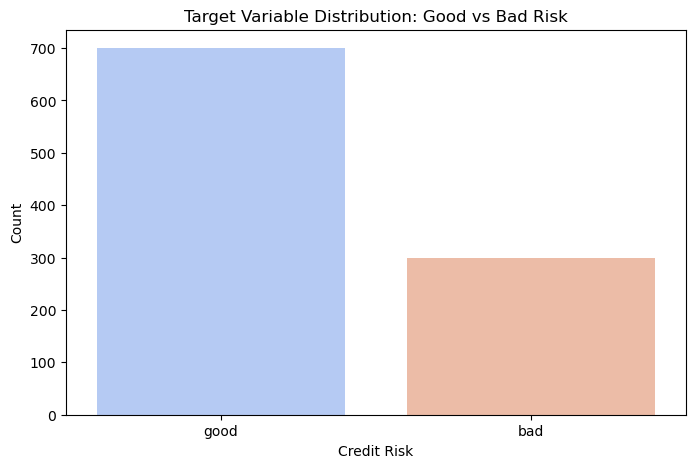

In [3]:
print("--- Dataset Info ---")
display(df_credit.info())
display(df_credit.head())

plt.figure(figsize=(8, 5))
sns.countplot(data=df_credit, x='Risk', palette='coolwarm')
plt.title('Target Variable Distribution: Good vs Bad Risk')
plt.ylabel('Count')
plt.xlabel('Credit Risk')
plt.show()

<h2>Creating an categorical variable to handle with the Age variable </h2>

In [4]:
#Let's look the Credit Amount column
interval = (18, 25, 35, 60, 120)

cats = ['Student', 'Young', 'Adult', 'Senior']
df_credit["Age_cat"] = pd.cut(df_credit.Age, interval, labels=cats)


df_good = df_credit[df_credit["Risk"] == 'good']
df_bad = df_credit[df_credit["Risk"] == 'bad']

Description of Distribuition Saving accounts by Risk:  
Risk             bad  good
Saving accounts           
little           217   386
moderate          34    69
quite rich        11    52
rich               6    42


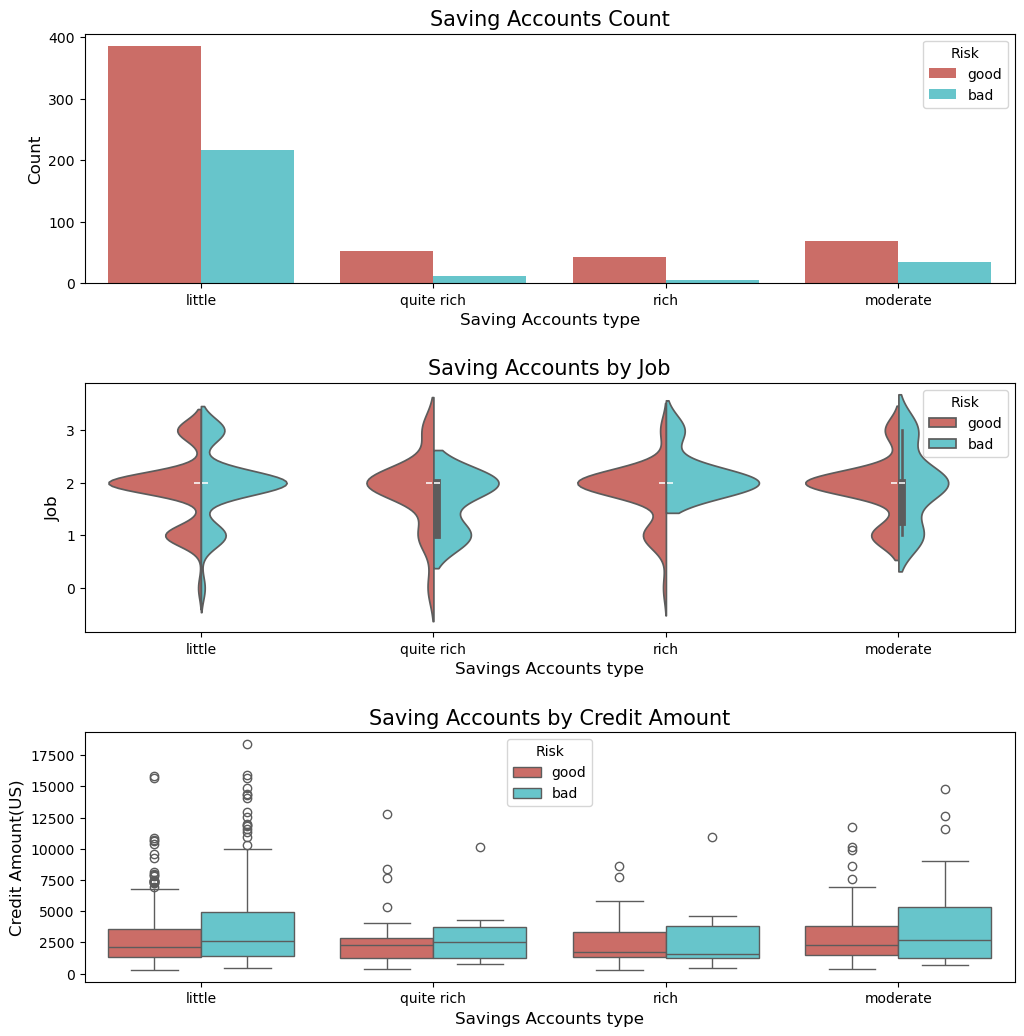

In [5]:
print("Description of Distribuition Saving accounts by Risk:  ")
print(pd.crosstab(df_credit["Saving accounts"],df_credit.Risk))

fig, ax = plt.subplots(3,1, figsize=(12,12))
g = sns.countplot(x="Saving accounts", data=df_credit, palette="hls", 
              ax=ax[0],hue="Risk")
g.set_title("Saving Accounts Count", fontsize=15)
g.set_xlabel("Saving Accounts type", fontsize=12)
g.set_ylabel("Count", fontsize=12)

g1 = sns.violinplot(x="Saving accounts", y="Job", data=df_credit, palette="hls", 
               hue = "Risk", ax=ax[1],split=True)
g1.set_title("Saving Accounts by Job", fontsize=15)
g1.set_xlabel("Savings Accounts type", fontsize=12)
g1.set_ylabel("Job", fontsize=12)

g2 = sns.boxplot(x="Saving accounts", y="Credit amount", data=df_credit, ax=ax[2],
            hue = "Risk",palette="hls")

g2.set_title("Saving Accounts by Credit Amount", fontsize=15)
g2.set_xlabel("Savings Accounts type", fontsize=12)
g2.set_ylabel("Credit Amount(US)", fontsize=12)

plt.subplots_adjust(hspace = 0.4, top = 0.9)
plt.show()


In [6]:
import plotly.graph_objs as go
import plotly.offline as py
py.init_notebook_mode(connected=True)

#First plot
trace0 = go.Bar(
    x = df_credit[df_credit["Risk"]== 'good']["Checking account"].value_counts().index.values,
    y = df_credit[df_credit["Risk"]== 'good']["Checking account"].value_counts().values,
    name='Good credit Distribuition' 
    
)

#Second plot
trace1 = go.Bar(
    x = df_credit[df_credit["Risk"]== 'bad']["Checking account"].value_counts().index.values,
    y = df_credit[df_credit["Risk"]== 'bad']["Checking account"].value_counts().values,
    name="Bad Credit Distribuition"
)

data = [trace0, trace1]

layout = go.Layout(
    title='Checking accounts Distribuition',
    xaxis=dict(title='Checking accounts name'),
    yaxis=dict(title='Count'),
    barmode='group'
)


fig = go.Figure(data=data, layout=layout)

py.iplot(fig, filename = 'Age-ba', validate = False)

In [7]:
print(pd.crosstab(df_credit.Sex, df_credit.Job))

Job      0    1    2    3
Sex                      
female  12   64  197   37
male    10  136  433  111


In [8]:
print(pd.crosstab(df_credit["Checking account"],df_credit.Sex))

Sex               female  male
Checking account              
little                88   186
moderate              86   183
rich                  20    43


In [9]:
date_int = ["Purpose", 'Sex']
cm = sns.light_palette("green", as_cmap=True)
pd.crosstab(df_credit[date_int[0]], df_credit[date_int[1]]).style.background_gradient(cmap = cm)

Sex,female,male
Purpose,,
business,19,78
car,94,243
domestic appliances,6,6
education,24,35
furniture/equipment,74,107
radio/TV,85,195
repairs,5,17
vacation/others,3,9


In [10]:
date_int = ["Purpose", 'Sex']
cm = sns.light_palette("green", as_cmap=True)
pd.crosstab(df_credit[date_int[0]], df_credit[date_int[1]]).style.background_gradient(cmap = cm)

Sex,female,male
Purpose,,
business,19,78
car,94,243
domestic appliances,6,6
education,24,35
furniture/equipment,74,107
radio/TV,85,195
repairs,5,17
vacation/others,3,9


In [11]:
print("Purpose : ",df_credit.Purpose.unique())
print("Sex : ",df_credit.Sex.unique())
print("Housing : ",df_credit.Housing.unique())
print("Saving accounts : ",df_credit['Saving accounts'].unique())
print("Risk : ",df_credit['Risk'].unique())
print("Checking account : ",df_credit['Checking account'].unique())
print("Aget_cat : ",df_credit['Age_cat'].unique())

Purpose :  ['radio/TV' 'education' 'furniture/equipment' 'car' 'business'
 'domestic appliances' 'repairs' 'vacation/others']
Sex :  ['male' 'female']
Housing :  ['own' 'free' 'rent']
Saving accounts :  [nan 'little' 'quite rich' 'rich' 'moderate']
Risk :  ['good' 'bad']
Checking account :  ['little' 'moderate' nan 'rich']
Aget_cat :  ['Senior', 'Student', 'Adult', 'Young']
Categories (4, object): ['Student' < 'Young' < 'Adult' < 'Senior']


In [12]:
def one_hot_encoder(df, nan_as_category = False):
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns= categorical_columns, dummy_na= nan_as_category, drop_first=True)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

In [13]:
df_credit['Saving accounts'] = df_credit['Saving accounts'].fillna('no_inf')
df_credit['Checking account'] = df_credit['Checking account'].fillna('no_inf')

#Purpose to Dummies Variable
df_credit = df_credit.merge(pd.get_dummies(df_credit.Purpose, drop_first=True, prefix='Purpose'), left_index=True, right_index=True)
#Sex feature in dummies
df_credit = df_credit.merge(pd.get_dummies(df_credit.Sex, drop_first=True, prefix='Sex'), left_index=True, right_index=True)
# Housing get dummies
df_credit = df_credit.merge(pd.get_dummies(df_credit.Housing, drop_first=True, prefix='Housing'), left_index=True, right_index=True)
# Housing get Saving Accounts
df_credit = df_credit.merge(pd.get_dummies(df_credit["Saving accounts"], drop_first=True, prefix='Savings'), left_index=True, right_index=True)
# Housing get Risk
df_credit = df_credit.merge(pd.get_dummies(df_credit.Risk, prefix='Risk'), left_index=True, right_index=True)
# Housing get Checking Account
df_credit = df_credit.merge(pd.get_dummies(df_credit["Checking account"], drop_first=True, prefix='Check'), left_index=True, right_index=True)
# Housing get Age categorical
df_credit = df_credit.merge(pd.get_dummies(df_credit["Age_cat"], drop_first=True, prefix='Age_cat'), left_index=True, right_index=True)

In [14]:
#Excluding the missing columns
del df_credit["Saving accounts"]
del df_credit["Checking account"]
del df_credit["Purpose"]
del df_credit["Sex"]
del df_credit["Housing"]
del df_credit["Age_cat"]
del df_credit["Risk"]
del df_credit['Risk_good']

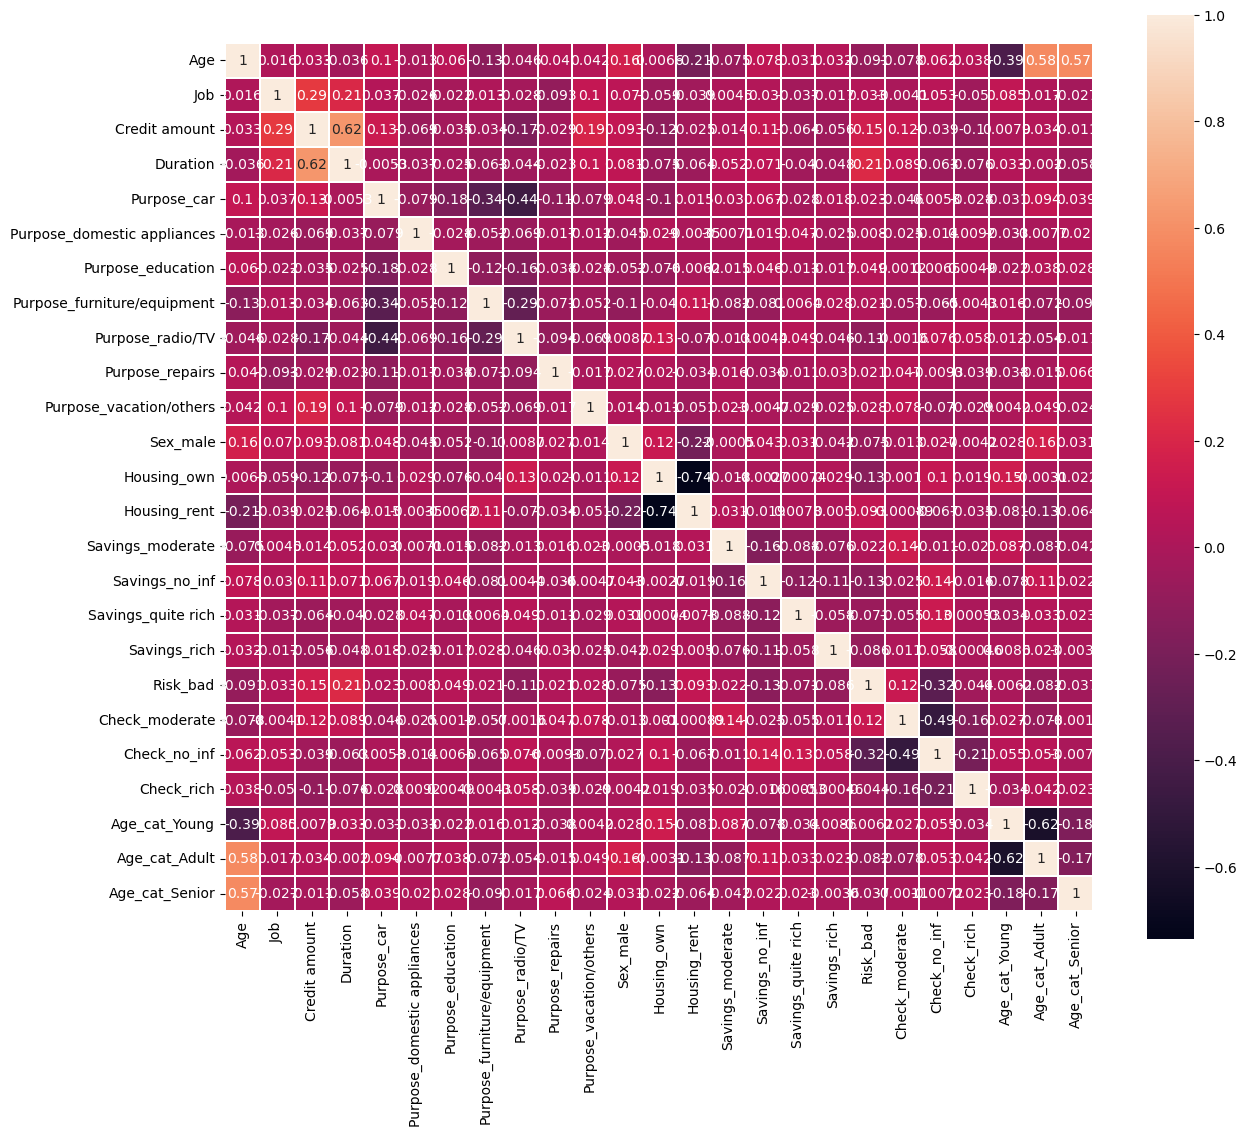

In [15]:
plt.figure(figsize=(14,12))
sns.heatmap(df_credit.astype(float).corr(),linewidths=0.1,vmax=1.0, 
            square=True,  linecolor='white', annot=True)
plt.show()

# **6. Preprocessing:** <a id="Preprocessing"></a> <br>
- Importing ML librarys
- Setting X and y variables to the prediction
- Splitting Data


In [16]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score # to split the data
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, fbeta_score #To evaluate our model

from sklearn.model_selection import GridSearchCV

# Algorithmns models to be compared
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier


In [17]:
df_credit['Credit amount'] = np.log(df_credit['Credit amount'])

In [18]:
#Creating the X and y variables
X = df_credit.drop('Risk_bad', axis=1).values
y = df_credit["Risk_bad"].values

# Spliting X and y into train and test version
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

LR: 0.399643 (0.083334)
LDA: 0.424515 (0.085843)
KNN: 0.282062 (0.079976)
CART: 0.472355 (0.060265)
NB: 0.610248 (0.074303)
RF: 0.368458 (0.069154)
SVM: 0.143989 (0.055608)
XGB: 0.491742 (0.064700)


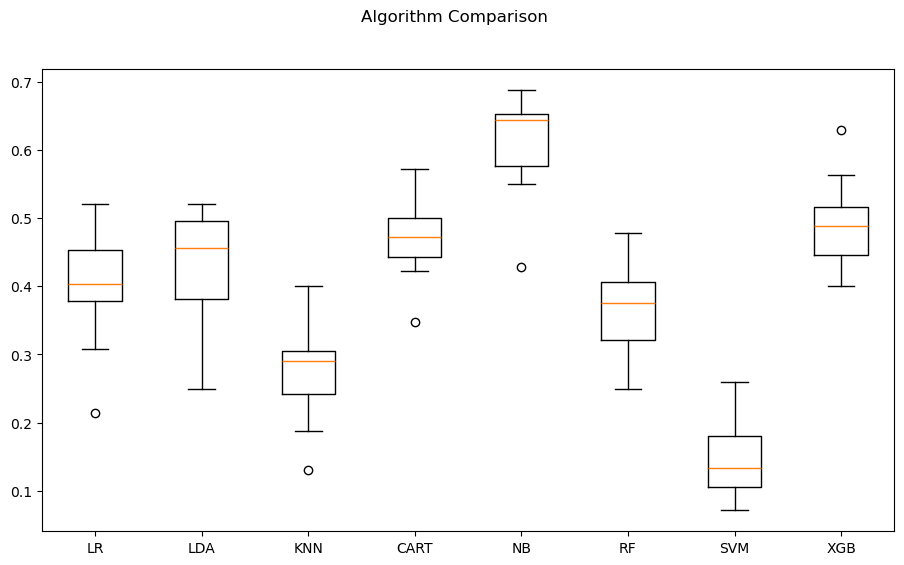

In [19]:
# to feed the random state
seed = 7

# prepare models
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('RF', RandomForestClassifier()))
models.append(('SVM', SVC(gamma='auto')))
models.append(('XGB', XGBClassifier()))

# evaluate each model in turn
results = []
names = []
scoring = 'recall'

for name, model in models:
        kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
        cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
        results.append(cv_results)
        names.append(name)
        msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
        print(msg)
        
# boxplot algorithm comparison
fig = plt.figure(figsize=(11,6))
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

# **7.1 Model 1 :** <a id="Modelling 1"></a> <br>
- Using Random Forest to predictict the credit score 
- Some of Validation Parameters

In [20]:
#Seting the Hyper Parameters
param_grid = {"max_depth": [3,5, 7, 10,None],
              "n_estimators":[3,5,10,25,50,150],
              "max_features": [4,7,15,20]}

#Creating the classifier
model = RandomForestClassifier(random_state=2)

grid_search = GridSearchCV(model, param_grid=param_grid, cv=5, scoring='recall', verbose=0)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=2),
             param_grid={'max_depth': [3, 5, 7, 10, None],
                         'max_features': [4, 7, 15, 20],
                         'n_estimators': [3, 5, 10, 25, 50, 150]},
             scoring='recall')

In [21]:
print(grid_search.best_score_)
print(grid_search.best_params_)

0.508792270531401
{'max_depth': None, 'max_features': 20, 'n_estimators': 3}


In [22]:
rf = RandomForestClassifier(max_depth=None, max_features=10, n_estimators=15, random_state=2)

#trainning with the best params
rf.fit(X_train, y_train)

RandomForestClassifier(max_features=10, n_estimators=15, random_state=2)

In [23]:
#Testing the model 
#Predicting using our  model
y_pred = rf.predict(X_test)

# Verificaar os resultados obtidos
print(accuracy_score(y_test,y_pred))
print("\n")
print(confusion_matrix(y_test, y_pred))
print("\n")
print(fbeta_score(y_test, y_pred, beta=2))

0.736


[[158  20]
 [ 46  26]]


0.3892215568862275


# **7.2 Model 2:** <a id="Modelling 2"></a> <br>

In [24]:
from sklearn.utils import resample
from sklearn.metrics import roc_curve

In [25]:
# Criando o classificador logreg
GNB = GaussianNB()

# Fitting with train data
model = GNB.fit(X_train, y_train)

In [26]:
# Printing the Training Score
print("Training score data: ")
print(model.score(X_train, y_train))

Training score data: 
0.7053333333333334


In [27]:
y_pred = model.predict(X_test)

print(accuracy_score(y_test,y_pred))
print("\n")
print(confusion_matrix(y_test, y_pred))
print("\n")
print(classification_report(y_test, y_pred))

0.648


[[124  54]
 [ 34  38]]


              precision    recall  f1-score   support

       False       0.78      0.70      0.74       178
        True       0.41      0.53      0.46        72

    accuracy                           0.65       250
   macro avg       0.60      0.61      0.60       250
weighted avg       0.68      0.65      0.66       250



With the Gaussian Model we got a best recall. 

## Let's verify the ROC curve

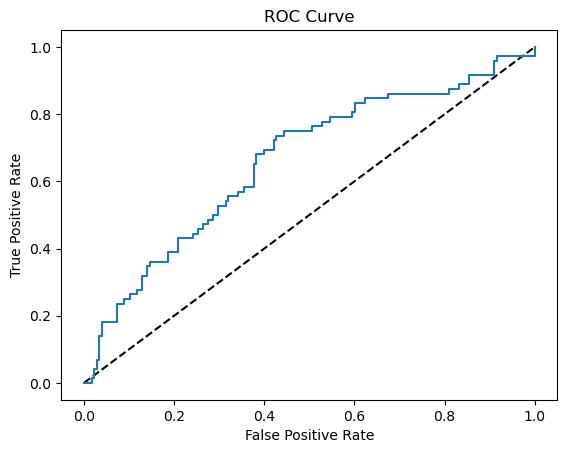

In [28]:
#Predicting proba
y_pred_prob = model.predict_proba(X_test)[:,1]

# Generate ROC curve values: fpr, tpr, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Plot ROC curve
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [29]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest

In [30]:
features = []
features.append(('pca', PCA(n_components=2)))
features.append(('select_best', SelectKBest(k=6)))
feature_union = FeatureUnion(features)
# create pipeline
estimators = []
estimators.append(('feature_union', feature_union))
estimators.append(('logistic', GaussianNB()))
model = Pipeline(estimators)
# evaluate pipeline
seed = 7
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
results = cross_val_score(model, X_train, y_train, cv=kfold)
print(results.mean())

0.6946666666666667


In [31]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(accuracy_score(y_test,y_pred))
print("\n")
print(confusion_matrix(y_test, y_pred))
print("\n")
print(fbeta_score(y_test, y_pred, beta=2))

0.72


[[149  29]
 [ 41  31]]


0.44540229885057464


## Implementing a pipeline of models 

In [32]:
#Seting the Hyper Parameters
param_test1 = {
 'max_depth':[3,5,6,10],
 'min_child_weight':[3,5,10],
 'gamma':[0.0, 0.1, 0.2, 0.3, 0.4],
# 'reg_alpha':[1e-5, 1e-2, 0.1, 1, 10],
 'subsample':[i/100.0 for i in range(75,90,5)],
 'colsample_bytree':[i/100.0 for i in range(75,90,5)]
}

#Creating the classifier
model_xg = XGBClassifier(random_state=2)

grid_search = GridSearchCV(model_xg, param_grid=param_test1, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.75, 0.8, 0.85],
                         'gamma': [0.0, 0.1, 0.2, 0.3, 0.4],
                         'max_depth': [3, 5, 6, 10],
                         'min_child_weight': [3, 5, 10],
                         'subsample': [0.75, 0.8, 0.85]},
             scoring='recall')

How can I avoid of this 

# Please, how can I increase this sucks models ?

In [33]:
grid_search.best_score_
grid_search.best_params_

{'colsample_bytree': 0.8,
 'gamma': 0.0,
 'max_depth': 5,
 'min_child_weight': 3,
 'subsample': 0.8}

In [34]:
y_pred = grid_search.predict(X_test)

# Verificaar os resultados obtidos
print(accuracy_score(y_test,y_pred))
print("\n")
print(confusion_matrix(y_test, y_pred))

0.736


[[151  27]
 [ 39  33]]


How can I avoid this error? 

/opt/conda/lib/python3.6/site-packages/sklearn/preprocessing/label.py:151: DeprecationWarning:

The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.


In [35]:
%pip install imodels

Note: you may need to restart the kernel to use updated packages.


In [36]:
from imodels import RuleFitClassifier
import pandas as pd

# Define the feature names so the extracted rules are readable
# (Since the notebook converts X to a numpy array, we pull the names from the dataframe)
feature_names = df_credit.drop(columns=['Risk_bad']).columns.tolist()

# 1. Initialize the RuleFit Model
# max_rules: Limits the number of rules generated to keep the model interpretable
# tree_size: Controls the maximum number of conditions in a single rule (e.g., 3 conditions)
rulefit_model = RuleFitClassifier(max_rules=50, tree_size=3, random_state=seed)

# 2. Fit the model to the training data
print("Training RuleFit model and extracting rules...")
rulefit_model.fit(X_train, y_train, feature_names=feature_names)

# 3. Extract the Distilled Rules into a DataFrame
# Using the internal method to generate the dataframe in newer imodels versions
rules_df = rulefit_model._get_rules()

# 4. Clean and Sort the Rules
# RuleFit creates both 'linear' features and 'rule' features. We just want the rules.
extracted_rules = rules_df[rules_df['type'] == 'rule'].copy()

# Sort the rules by their absolute coefficient (which dictates their impact on the prediction)
extracted_rules['importance'] = extracted_rules['coef'].abs()
top_rules = extracted_rules.sort_values(by='importance', ascending=False)



Training RuleFit model and extracting rules...


In [37]:
# Display the top 10 most impactful rules
print("\n--- Top 10 Extracted Rules ---")
top_rules_display = top_rules[['rule', 'coef', 'support']].head(10)
display(top_rules_display)


--- Top 10 Extracted Rules ---


,rule,coef,support
30,Age > 35.5 and Credit amount <= 8.26769,-0.839793,0.292000
44,Age <= 26.5 and Check_no_inf <= 0.5 and Durati...,-0.743200,0.098667
56,Check_no_inf <= 0.5 and Credit amount <= 7.2391,0.654063,0.166667
54,Savings_no_inf <= 0.5 and Check_no_inf <= 0.5 ...,0.540565,0.217333
36,Check_no_inf > 0.5 and Duration > 22.5,-0.517121,0.166667
29,Age > 25.5 and Check_moderate > 0.5 and Check_...,-0.515670,0.177333
43,Check_no_inf <= 0.5 and Credit amount <= 7.68789,0.504673,0.276000
26,Check_no_inf <= 0.5 and Check_rich > 0.5,-0.498612,0.060000
57,Age <= 35.5 and Sex_male <= 0.5 and Purpose_ra...,0.491838,0.166667
38,Credit amount <= 8.96094 and Duration <= 31.5,-0.488972,0.793333


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# 1. Generate predictions and probabilities on the test set
y_pred = rulefit_model.predict(X_test)

# RuleFit predict_proba outputs probabilities for both classes [Prob_0, Prob_1]
# We slice [:, 1] to get the probability of the positive class (Risk_bad = 1)
y_pred_proba = rulefit_model.predict_proba(X_test)[:, 1]

# 2. Calculate core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# 3. Display the results
print("--- RuleFit Model Performance ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

--- RuleFit Model Performance ---
Accuracy:  0.7400
Precision: 0.6522
Recall:    0.2083
F1 Score:  0.3158
ROC AUC:   0.7619

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.75      0.96      0.84       178
        True       0.65      0.21      0.32        72

    accuracy                           0.74       250
   macro avg       0.70      0.58      0.58       250
weighted avg       0.72      0.74      0.69       250

--- Confusion Matrix ---
[[170   8]
 [ 57  15]]


In [39]:
# 1. Start with the full rules dataframe from earlier
# rules_df = rulefit_model._get_rules() # Make sure you have this

# 2. Create a dictionary to store the total importance of each original feature
feature_importances = {feature: 0.0 for feature in feature_names}

# 3. Calculate importance
# We iterate through every rule/linear term in the RuleFit model
for index, row in rules_df.iterrows():
    condition = str(row['rule'])
    # The impact is the absolute value of the coefficient
    impact = abs(row['coef'])
    
    # Check which original features are mentioned in this rule/linear term
    for feature in feature_names:
        # We check if the feature name is in the string. 
        # (Note: if you have features with overlapping names like 'Check' and 'Check_status', 
        # you might need exact word boundaries, but this works well for standard names)
        if feature in condition:
            feature_importances[feature] += impact

# 4. Convert to a sorted DataFrame for easy viewing
importance_df = pd.DataFrame(list(feature_importances.items()), columns=['Feature', 'Total_Importance'])
importance_df = importance_df.sort_values(by='Total_Importance', ascending=False).reset_index(drop=True)

# 5. Display the top 10 most important features overall
print("\n--- Global Feature Importance (Top 10) ---")
display(importance_df.head(10))


--- Global Feature Importance (Top 10) ---


,Feature,Total_Importance
0,Check_no_inf,5.733380
1,Credit amount,5.404737
2,Duration,4.962220
3,Age,3.792999
4,Savings_no_inf,1.468957
5,Check_rich,0.871099
6,Purpose_car,0.743200
7,Purpose_radio/TV,0.725436
8,Savings_rich,0.651294
9,Housing_own,0.646724



--- Corrected XGBoost Feature Importance ---


,Feature,Importance_Gain
0,Check_no_inf,5.447990
1,Savings_quite rich,2.080511
2,Check_rich,1.667623
3,Savings_no_inf,1.658271
4,Housing_own,1.588394
5,Savings_rich,1.486571
6,Age_cat_Adult,1.353938
7,Credit amount,1.314099
8,Duration,1.304430
9,Purpose_radio/TV,1.289656


<Figure size 1000x600 with 0 Axes>

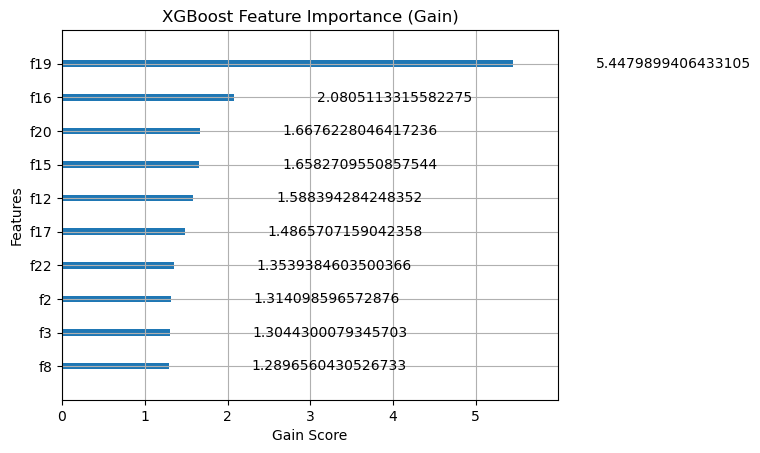

In [40]:
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have trained an XGBoost model named 'xgb_model'
# e.g., xgb_model = xgb.XGBClassifier(random_state=seed)
#       xgb_model.fit(X_train, y_train)

# 1. Extract feature importance using the 'gain' metric
importance_dict = grid_search.best_estimator_.get_booster().get_score(importance_type='gain')

# 2. Convert the dictionary into a clean Pandas DataFrame
xgb_importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance_Gain': list(importance_dict.values())
})

# 3. Sort the features from most to least important
xgb_importance_df = xgb_importance_df.sort_values(by='Importance_Gain', ascending=False).reset_index(drop=True)

# 1. Create a dictionary mapping 'f0', 'f1', etc. to the actual feature names
# enumerate() pairs the index (0, 1, 2) with the feature name
feature_map = {f'f{i}': name for i, name in enumerate(feature_names)}

# 2. Map the actual names back onto your 'Feature' column
xgb_importance_df['Feature'] = xgb_importance_df['Feature'].map(feature_map)

# 3. Display the corrected top 10
print("\n--- Corrected XGBoost Feature Importance ---")
display(xgb_importance_df.head(10))


# 5. Bonus: XGBoost's built-in plotting method
plt.figure(figsize=(10, 6))
xgb.plot_importance(grid_search.best_estimator_, importance_type='gain', max_num_features=10, 
                    title='XGBoost Feature Importance (Gain)', xlabel='Gain Score')
plt.show()

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming the Random Forest model from the notebook is named 'random_forest'
# (Check the exact variable name in your notebook, it might be 'rf_model' or 'model')
rf_importances = rf.feature_importances_

# 1. Create a DataFrame linking your saved feature names directly to the Gini values
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Gini': rf_importances
})

# 2. Sort the features from most to least important
rf_importance_df = rf_importance_df.sort_values(by='Importance_Gini', ascending=False).reset_index(drop=True)

# 3. Display the top 10 most important features
print("\n--- Random Forest Feature Importance (Top 10 by Gini) ---")
display(rf_importance_df.head(10))




--- Random Forest Feature Importance (Top 10 by Gini) ---


,Feature,Importance_Gini
0,Credit amount,0.243763
1,Age,0.170661
2,Duration,0.141455
3,Check_no_inf,0.087483
4,Job,0.051559
5,Purpose_radio/TV,0.030136
6,Check_moderate,0.027155
7,Purpose_car,0.027062
8,Housing_own,0.025699
9,Sex_male,0.024176


In [42]:
print("--- Starting Rule Distillation (Global Surrogate Model) ---")

# 1. The opaque model (XGBoost) makes predictions on the training data.
# We use these XGBoost predictions as our new "Target" (y) for the surrogate.
y_train_blackbox = grid_search.best_estimator_.predict(X_train)

# 2. Initialize a new RuleFit model (The Surrogate Model).
rulefit_surrogate = RuleFitClassifier(max_rules=50, tree_size=3, random_state=seed)

# 3. Train RuleFit using the XGBoost predictions 
# instead of the ground truth (y_train).
rulefit_surrogate.fit(X_train, y_train_blackbox, feature_names=feature_names)

# 4. Extract, clean, and sort the rules that explain the XGBoost behavior.
rules_df_surrogate = rulefit_surrogate._get_rules()
extracted_surrogate = rules_df_surrogate[rules_df_surrogate['type'] == 'rule'].copy()
extracted_surrogate['importance'] = extracted_surrogate['coef'].abs()
top_rules_surrogate = extracted_surrogate.sort_values(by='importance', ascending=False)

print("\n--- Top 10 Rules explaining the Black Box (XGBoost) ---")
display(top_rules_surrogate[['rule', 'coef', 'support']].head(10))

# 5. Calculate Fidelity: Check how faithful RuleFit is at imitating XGBoost on unseen data.
from sklearn.metrics import accuracy_score
y_pred_surrogate = rulefit_surrogate.predict(X_test)
y_pred_blackbox_test = grid_search.best_estimator_.predict(X_test)

fidelity = accuracy_score(y_pred_blackbox_test, y_pred_surrogate)
print(f"\nSurrogate Model Fidelity: {fidelity:.4f}")
print("(A high percentage means RuleFit accurately mimics XGBoost's decisions)")

--- Starting Rule Distillation (Global Surrogate Model) ---

--- Top 10 Rules explaining the Black Box (XGBoost) ---


,rule,coef,support
52,Check_no_inf <= 0.5 and Credit amount <= 7.2291,1.176895,0.164000
41,Credit amount <= 8.9568 and Duration <= 45.0,-0.853708,0.874667
54,Savings_no_inf <= 0.5 and Check_no_inf <= 0.5 ...,0.813918,0.217333
49,Check_no_inf <= 0.5 and Duration > 7.0,0.795831,0.562667
56,Age <= 35.5 and Check_no_inf <= 0.5 and Durati...,0.757919,0.064000
53,Age <= 35.5 and Sex_male <= 0.5 and Purpose_ra...,0.680681,0.166667
58,Age <= 23.5 and Check_no_inf > 0.5 and Credit ...,0.594372,0.022667
37,Age > 25.5 and Housing_own > 0.5,-0.505219,0.601333
42,Credit amount <= 9.29816,-0.492429,0.964000
27,Age > 35.5 and Credit amount <= 8.26769,-0.458711,0.292000



Surrogate Model Fidelity: 0.8400
(A high percentage means RuleFit accurately mimics XGBoost's decisions)


In [43]:
print("--- Starting Rule Distillation for Random Forest ---")

# 1. Use the Random Forest predictions as the new Target (y)
y_train_rf_blackbox = rf.predict(X_train)

# 2. Initialize a new RuleFit model (The Surrogate)
rulefit_rf_surrogate = RuleFitClassifier(max_rules=50, tree_size=3, random_state=seed)

# 3. Train RuleFit to mimic the Random Forest's behavior
rulefit_rf_surrogate.fit(X_train, y_train_rf_blackbox, feature_names=feature_names)

# 4. Extract, clean, and sort the rules that explain the Random Forest
rules_df_rf = rulefit_rf_surrogate._get_rules()
extracted_rf = rules_df_rf[rules_df_rf['type'] == 'rule'].copy()
extracted_rf['importance'] = extracted_rf['coef'].abs()
top_rules_rf = extracted_rf.sort_values(by='importance', ascending=False)

print("\n--- Top 10 Rules explaining the Random Forest ---")
display(top_rules_rf[['rule', 'coef', 'support']].head(10))

# 5. Calculate the Fidelity of the Random Forest Surrogate
y_pred_rf_surrogate = rulefit_rf_surrogate.predict(X_test)
y_pred_rf_test = rf.predict(X_test)

fidelity_rf = accuracy_score(y_pred_rf_test, y_pred_rf_surrogate)
print(f"\nRandom Forest Surrogate Fidelity: {fidelity_rf:.4f}")

--- Starting Rule Distillation for Random Forest ---

--- Top 10 Rules explaining the Random Forest ---


,rule,coef,support
52,Savings_no_inf <= 0.5 and Check_no_inf <= 0.5 ...,1.010911,0.217333
45,Age <= 26.5 and Check_no_inf <= 0.5 and Durati...,-0.815369,0.098667
53,Check_no_inf <= 0.5 and Credit amount <= 7.2349,0.797174,0.166667
29,Age > 35.5 and Credit amount <= 8.26769,-0.763004,0.292000
58,Age <= 28.5 and Credit amount > 8.76534,0.600868,0.033333
32,Check_no_inf > 0.5 and Credit amount <= 8.27219,-0.591614,0.296000
54,Age <= 35.5 and Sex_male <= 0.5 and Purpose_ra...,0.492505,0.166667
42,Check_no_inf <= 0.5 and Credit amount <= 7.68789,0.478833,0.276000
39,Credit amount <= 8.9568 and Duration <= 45.0,-0.431172,0.874667
46,Housing_own <= 0.5 and Credit amount <= 8.36077,0.426361,0.194667



Random Forest Surrogate Fidelity: 0.8920


In [44]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# 1. We MUST scale the data for Neural Networks to work properly
print("--- Phase 1: Data Scaling ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data scaling completed.")

print("\n--- Phase 2: Training Keras Deep Neural Network (DNN) ---")
# Import TensorFlow/Keras (Required by REMIX/ECLAIRE)
try:
    from tensorflow import keras
    from tensorflow.keras import layers
    
    # Building a Deep Neural Network (64 -> 32 -> 16 -> 1)
    keras_dnn = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification (Good/Bad)
    ])
    
    # Compile the model
    keras_dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    print("Training DNN... (Verbose is off to avoid wall of text)")
    # Train the model
    keras_dnn.fit(X_train_scaled, y_train, epochs=100, batch_size=16, verbose=0)
    
    # Predict and evaluate
    y_pred_prob = keras_dnn.predict(X_test_scaled, verbose=0)
    y_pred_dnn = (y_pred_prob > 0.5).astype(int).flatten()
    print(f"Keras DNN Accuracy: {accuracy_score(y_test, y_pred_dnn):.4f}")

except ImportError:
    print("[!] ERROR: TensorFlow/Keras is not installed. Please run 'pip install tensorflow'")

print("\n--- Phase 3: Rule Extraction with ECLAIRE ---")
try:
    # Importing ECLAIRE exactly as the README specifies
    from remix import eclaire
    
    print("Extracting rules from the trained Keras model...")
    # The signature requires the Keras model and the training data
    ruleset = eclaire.extract_rules(keras_dnn, X_train_scaled)
    
    print("\n--- ECLAIRE Extracted Ruleset ---")
    # According to the README, we can just print the ruleset object
    print(ruleset)
    
    # Optional: Calculate fidelity of the ECLAIRE ruleset
    print("\nCalculating Ruleset predictions and Fidelity...")
    y_pred_eclaire = ruleset.predict(X_test_scaled)
    fidelity_eclaire = accuracy_score(y_pred_dnn, y_pred_eclaire)
    print(f"ECLAIRE Fidelity (vs Keras DNN): {fidelity_eclaire:.4f}")

except ImportError as e:
    print(f"\n[!] ERROR importing REMIX: {e}")
    print("Make sure you have installed it via 'python setup.py install --user'")
    print("and that your R environment and rpy2 are correctly configured as per the README.")

--- Phase 1: Data Scaling ---
Data scaling completed.

--- Phase 2: Training Keras Deep Neural Network (DNN) ---
[!] ERROR: TensorFlow/Keras is not installed. Please run 'pip install tensorflow'

--- Phase 3: Rule Extraction with ECLAIRE ---

[!] ERROR importing REMIX: No module named 'remix'
Make sure you have installed it via 'python setup.py install --user'
and that your R environment and rpy2 are correctly configured as per the README.
